In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sunraster.instr.spice import read_spice_l2_fits
import h5py
import sunpy 
import sunpy.map
from sharpesst.correct_2d_psf import get_fwd_matrices, correct_spice_raster
from sharpesst.util import bindown, as_dict, get_iris_data, masked_median_filter, get_mask_errs
from sharpesst.fit_spice_lines import get_overall_center, fit_spice_lines as fsl
import astropy
from astropy.visualization import (ImageNormalize, AsinhStretch)
from astropy import constants as const
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
import juanfit
import importlib
importlib.reload(juanfit)
from juanfit import SpectrumFit2D, gaussian, SpectrumFitSingle, SpectrumFitRow
from scipy.signal import find_peaks
from sospice import spice_error
from scipy.optimize import curve_fit
import os
import itertools
from concurrent.futures import ProcessPoolExecutor
import logging

from copy import deepcopy
from glob import glob

In [84]:
def gaussian_with_bg(x, wvl, int_total, width, bg):
    return gaussian(x, wvl, int_total, width) + bg

def work(args, position=387//2):
    (spice_dat1, spice_hdr, 
    fwhm_core0_yl, fwhm_wing0_yl, psf_yl_angle, wing_weight, 
    yl_core_xpo, yl_wing_xpo, rebin_facs, spice_orig_fit_int,
    spice_orig_fit_wvl, spice_orig_fit_wid,
    spice_la,)= args

    spice_corr_dat, spice_corr_chi2s, metadict = correct_spice_raster(spice_dat1, spice_hdr, fwhm_core0_yl, fwhm_wing0_yl, 
                                                                    psf_yl_angle, wing_weight, yl_core_xpo=yl_core_xpo,
                                                                    yl_wing_xpo=yl_wing_xpo,
                                                                    super_fac=1, chi2_th = 0.5,
                                                                    psf_thold_core=0.0005, spice_bin_facs = rebin_facs)
    spice_corr_dat = spice_corr_dat.transpose([2,1,0])

    NeVIII_row_20_corr_fit_wvl = np.zeros(25)
    NeVIII_row_20_corr_fit_int = np.zeros(25)
    NeVIII_row_20_corr_fit_wid = np.zeros(25)

    for ii in range(175,200):
        popt, pcov = curve_fit(gaussian_with_bg,
                            spice_la[np.r_[3:17,27:42]],
                            spice_corr_dat[np.r_[3:17,27:42], ii, 0],
                            p0=[spice_la[np.nanargmax(spice_corr_dat[:,ii,0])],
                            np.nanmax(spice_corr_dat[:,ii,0]),
                            0.7, np.nanmean(spice_corr_dat[3:15,ii,0])])

        NeVIII_row_20_corr_fit_int[ii-175] = popt[1]
        NeVIII_row_20_corr_fit_wvl[ii-175] = popt[0]
        NeVIII_row_20_corr_fit_wid[ii-175] = popt[2]
    
    logging.info(f"Processed: {args[2:7]}")

    print(metadict)
    

    if True: #np.nanstd(NeVIII_row_20_corr_fit_wvl[5:]) < 1*np.nanstd(spice_orig_fit_wvl[5:]):
        fig = plt.figure(figsize=(8,6),layout="constrained")
        axd = fig.subplot_mosaic(
            """
            AD
            BE
            CF
            CG
            """
        )

        axd["A"].imshow(spice_dat1[0,:,:].T, origin="lower",
                norm=ImageNormalize(vmin=np.nanpercentile(spice_dat1[0,:,:], 3),
                                    vmax=np.nanpercentile(spice_dat1[0,:,:], 99.95),
                                    stretch=AsinhStretch(0.5)), aspect=1)
        axd["B"].imshow(spice_corr_dat[:,:,0], origin="lower",
                norm=ImageNormalize(vmin=np.nanpercentile(spice_corr_dat[:,:,0], 3),
                                    vmax=np.nanpercentile(spice_corr_dat[:,:,0], 99.95),
                                    stretch=AsinhStretch(0.05)), aspect=0.5)

        axd["C"].step(spice_la, spice_dat1[0,position,:], where="mid")
        axd["C"].step(spice_la, spice_corr_dat[:,position,0], where="mid")

        axd["D"].plot(spice_orig_fit_int)
        axd["D"].plot(NeVIII_row_20_corr_fit_int)
        axd["E"].plot(spice_orig_fit_wvl)
        axd["E"].plot(NeVIII_row_20_corr_fit_wvl)
        axd["F"].plot(spice_orig_fit_wid)
        axd["F"].plot(NeVIII_row_20_corr_fit_wid)

        axd["D"].set_ylim(0,5)
        axd["E"].set_ylim(770.0, 770.4)
        axd["F"].set_ylim(0.3,1)

        axd["G"].axis("off")
        axd["G"].text(0.2, 0.9, f"sigma_wvl_orig: {np.nanstd(spice_orig_fit_wvl[5:]):.4f}")
        axd["G"].text(0.2, 0.7, f"sigma_wvl_corr: {np.nanstd(NeVIII_row_20_corr_fit_wvl[5:]):.4f}")
        axd["G"].text

In [3]:
raster_files = sorted(glob("/cluster/home/zhuyin/Solar/SPICE_psf_202210/src/full_detector/level2/2022/10/24/*.fits"))

test_raster_cube = read_spice_l2_fits(raster_files[0])
sw_data = np.ones((test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[1],
                test_raster_cube['Full SW 4:1 Focal Lossy'].data.shape[2],
                len(raster_files)))*np.nan

lw_data = np.ones((test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[1],
                    test_raster_cube['Full LW 4:1 Focal Lossy'].data.shape[2],
                    len(raster_files)))*np.nan

sw_wcs_list = []
lw_wcs_list = []
sw_meta_list = []
lw_meta_list = []
sw_wvl_list = []
lw_wvl_list = []

for ii, file_ in enumerate(raster_files):
    datacube_ = read_spice_l2_fits(file_)
    sw_data[:,:,ii] = datacube_['Full SW 4:1 Focal Lossy'].data[0,:,:,0]
    lw_data[:,:,ii] = datacube_['Full LW 4:1 Focal Lossy'].data[0,:,:,0]
    sw_wcs_list.append(datacube_['Full SW 4:1 Focal Lossy'].wcs)
    lw_wcs_list.append(datacube_['Full LW 4:1 Focal Lossy'].wcs)
    sw_meta_list.append(datacube_['Full SW 4:1 Focal Lossy'].meta)
    lw_meta_list.append(datacube_['Full LW 4:1 Focal Lossy'].meta)
    sw_wvl_list.append(datacube_['Full SW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
    lw_wvl_list.append(datacube_['Full LW 4:1 Focal Lossy'].spectral_axis.to_value(u.AA))
sw_data = np.flip(sw_data, axis=-1)
lw_data = np.flip(lw_data, axis=-1)

test_fit_NeVIII_wvl = sw_wvl_list[0][735:799]

with fits.open(raster_files[-21]) as hdul:
    spice_hdr_20 = hdul[0].header.copy()

spice_hdr_20_NeVIII = deepcopy(spice_hdr_20)
spice_hdr_20_NeVIII_new_naxis3 = 799 - 735
spice_hdr_20_NeVIII_new_crpix3 = (1 + 799 - 735)/2
spice_hdr_20_NeVIII_new_crval3 =  ((736 + 799)/2 - spice_hdr_20_NeVIII["CRPIX3"])*spice_hdr_20_NeVIII["CDELT3"] + spice_hdr_20_NeVIII["CRVAL3"]
spice_hdr_20_NeVIII["NAXIS3"] = spice_hdr_20_NeVIII_new_naxis3 
spice_hdr_20_NeVIII["CRPIX3"] = spice_hdr_20_NeVIII_new_crpix3
spice_hdr_20_NeVIII["CRVAL3"] = spice_hdr_20_NeVIII_new_crval3

test_NeVIII_data = sw_data[735:799,210:790,:]
test_NeVIII_data_bg_rm = test_NeVIII_data - np.nanmean(test_NeVIII_data, axis=2)[:,:,np.newaxis]

rebin_facs = [1,2,1]

test_NeVIII_data_bin = bindown(test_NeVIII_data_bg_rm,np.round(np.array(test_NeVIII_data_bg_rm.shape)/rebin_facs).astype(np.int32))
test_NeVIII_data_bin_trans = deepcopy(test_NeVIII_data_bin[:,:,20:22]).transpose([2,1,0]).astype(np.float64)

NeVIII_row_20_orig_fit_wvl = np.zeros(25)
NeVIII_row_20_orig_fit_int = np.zeros(25)
NeVIII_row_20_orig_fit_wid = np.zeros(25)

for ii in range(175,200):
    popt, pcov = curve_fit(gaussian_with_bg,
                        test_fit_NeVIII_wvl[np.r_[3:17,27:42]],
                        test_NeVIII_data_bin[np.r_[3:17,27:42], ii, 20],
                        p0=[test_fit_NeVIII_wvl[np.nanargmax(test_NeVIII_data_bin[:,ii,20])],
                        np.nanmax(test_NeVIII_data_bin[:,ii,20]),
                        0.7, np.nanmean(test_NeVIII_data_bin[3:15,ii,20])])
    
    NeVIII_row_20_orig_fit_int[ii-175] = popt[1]
    NeVIII_row_20_orig_fit_wvl[ii-175] = popt[0]
    NeVIII_row_20_orig_fit_wid[ii-175] = popt[2]

keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-04 11:18:04 - astropy - WARNING: FITSFixedWarning: CROTA = 4.74638738770 / [deg] S/C counter-clockwise roll rel to Solar N
keyword looks very much like CROTAn but isn't.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'. [astropy.wcs.wcs]
2025-03-04 11:18:04 - astropy - WARNING: FITSFixedWarning: 'datfix' made the change 'Set MJDREF to 59876.928116 from DATEREF.
Set MJD-OBS to 59876.928116 from DATE-OBS.
Set MJD-BEG to 59876.928116 from DATE-BEG.
Set MJD-AVG to 59876.928461 from DATE-AVG.
Set MJD-END to 59876.928806 from DATE-END'.
2025-03-04 11:18:04 - astropy - WARNING: UnitsWarning: 'W/m2/sr/nm' contains multiple slashes, which is discouraged by the FITS standard
keyword looks very much like CROTAn but isn't. [astropy.wcs.wcs]
2025-03-04 11:18:05 - astropy - WARNING: FITSFixedWarning: CROTA 

In [4]:
spice_hdr_20_NeVIII

SIMPLE  =                    T / Written by IDL:  Mon Oct 30 09:29:54 2023      
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    4 / Number of dimensions                           
NAXIS1  =                    1 / Number of slit positions (x)                   
NAXIS2  =                 1024 / Number of pixels along slit (y)                
NAXIS3  =                   64 / Number of pixels in dispersion dimension       
NAXIS4  =                    1 / Number of exposures per slit position (time)   
EXTEND  =                    T /  FITS dataset may contain extensions           
DATE    = '2023-10-31T12:26:39' / Date and time of FITS file creation           
                                                                                
EXTNAME = 'Full SW 4:1 Focal Lossy' / Extension name                            
FILENAME= 'solo_L2_spice-n-exp_20221024T223223_V04_150995397-009.fits' / Filenam
                            

In [38]:
def func_NeVIII_sg(x, wvl_770, int_770, wid_770, a, b):
    return gaussian(x, wvl_770, int_770, wid_770,) + a*x + b
    
def func_NeVIII_dg(x, wvl_770, int_770, wid_770, a, b, alpha, beta):
    return gaussian(x, wvl_770, int_770, wid_770,) + \
           gaussian(x, wvl_770, int_770*alpha, wid_770*beta,) + \
           a*x + b

In [47]:
NeVIII_770_387_wvl = test_fit_NeVIII_wvl[np.r_[3:17,27:48]]
NeVIII_770_387_int = test_NeVIII_data_bin_trans[0,387//2,np.r_[3:17,27:48]]
NeVIII_770_387_wvl_all = test_fit_NeVIII_wvl[:48]
NeVIII_770_387_int_all = test_NeVIII_data_bin_trans[0,387//2,:48]

NeVIII_770_sg_popt, NeVIII_770_sg_pcov = curve_fit(func_NeVIII_sg,
                                                  NeVIII_770_387_wvl,
                                                  NeVIII_770_387_int,
                                                  p0=[NeVIII_770_387_wvl[np.nanargmax(NeVIII_770_387_int)],
                                                  np.nanmax(NeVIII_770_387_int),0.7,
                                                  0.0, 0], 
                                                  maxfev=5000)

[ 7.70200020e+02  4.33885466e+00  8.63997582e-01  2.48288511e-02
 -1.88309988e+01]


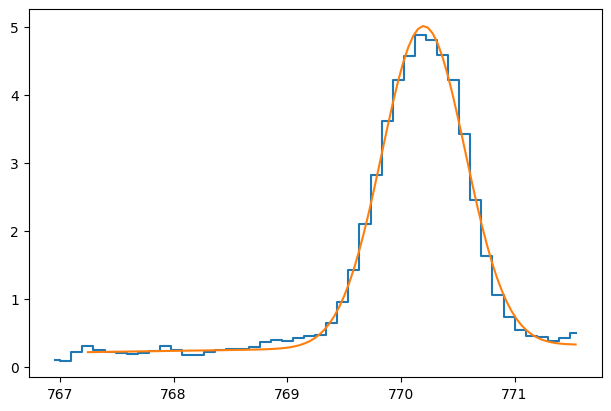

In [48]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(NeVIII_770_387_wvl_all, NeVIII_770_387_int_all, where="mid")
ax.plot(np.linspace(NeVIII_770_387_wvl[0], NeVIII_770_387_wvl[-1], 100),
        func_NeVIII_sg(np.linspace(NeVIII_770_387_wvl[0], NeVIII_770_387_wvl[-1], 100), *NeVIII_770_sg_popt))
print(NeVIII_770_sg_popt)

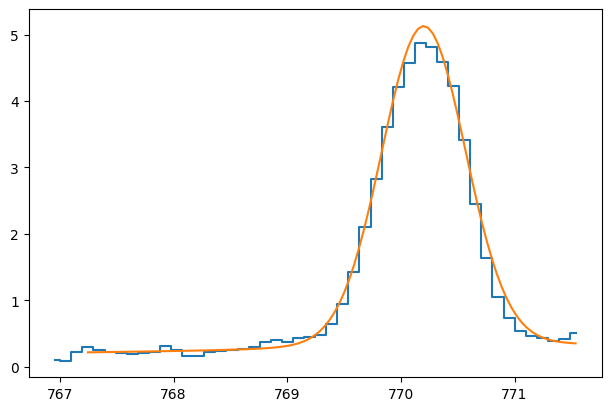

In [49]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(NeVIII_770_387_wvl_all, NeVIII_770_387_int_all, where="mid")
ax.plot(np.linspace(NeVIII_770_387_wvl[0], NeVIII_770_387_wvl[-1], 100),
        func_NeVIII_dg(np.linspace(NeVIII_770_387_wvl[0], NeVIII_770_387_wvl[-1], 100), *NeVIII_770_sg_popt, 0.05, 2))

In [50]:
NeVIII_dg_popt, NeVIII_dg_pcov = curve_fit(func_NeVIII_dg,
                                          NeVIII_770_387_wvl,
                                          NeVIII_770_387_int,
                                          p0=[*NeVIII_770_sg_popt,
                                          0.01, 2], 
                                          bounds=((0,0,0,-np.inf,-np.inf,0,0), (np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf)),
                                          maxfev=5000)

[ 7.70200020e+02  4.33885236e+00  8.63997035e-01  2.48290438e-02
 -1.88311466e+01  1.34576784e-06  1.41904957e+02]


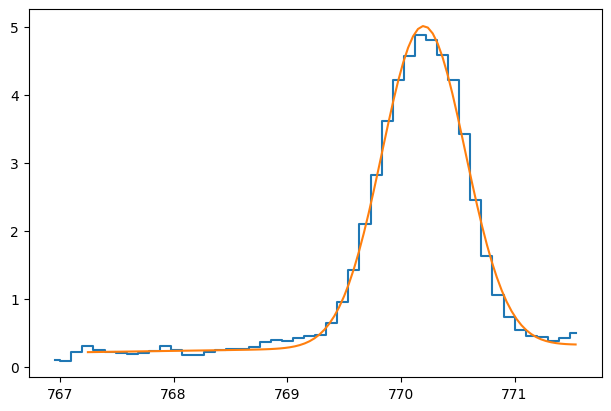

In [51]:
fig, ax = plt.subplots(figsize=(6,4),layout="constrained")
ax.step(NeVIII_770_387_wvl_all, NeVIII_770_387_int_all, where="mid")
ax.plot(np.linspace(NeVIII_770_387_wvl[0], NeVIII_770_387_wvl[-1], 100),
        func_NeVIII_dg(np.linspace(NeVIII_770_387_wvl[0], NeVIII_770_387_wvl[-1], 100), *NeVIII_dg_popt))
print(NeVIII_dg_popt)

Correcting Full SW 4:1 Focal Lossy; ref. wavelength=766.8564825000001
Computing PSF Core:
4.9948811897192735 % done after 1.3692729473114014 seconds
9.99515060078668 % done after 2.7328929901123047 seconds
14.995420011854087 % done after 4.098466873168945 seconds
19.995689422921494 % done after 5.4732489585876465 seconds
24.9959588339889 % done after 6.845373868942261 seconds
29.996228245056308 % done after 8.217439651489258 seconds
34.996497656123715 % done after 9.59362268447876 seconds
39.99676706719112 % done after 10.964313507080078 seconds
44.99703647825853 % done after 12.33308458328247 seconds
49.997305889325936 % done after 13.710419654846191 seconds
54.99757530039334 % done after 15.081367492675781 seconds
59.99784471146074 % done after 16.464132070541382 seconds
64.99811412252815 % done after 17.844301462173462 seconds
69.99838353359556 % done after 19.219987869262695 seconds
74.99865294466296 % done after 20.602285146713257 seconds
79.99892235573037 % done after 21.98279094

2025-03-04 16:04:18 - root - INFO: Processed: (array([1.5 , 1.11]), array([8. , 4.5]), -0.17453292519943295, 0.28, 1.8)


3.661865711212158 s; Finished slit index 1 of 2 , chi^2= 0.22425459386129817
{'det_scale0': array([16.36363636, 36.        , 19.5034    ]), 'det_dims0': array([  2, 290,  64]), 'det_origin0': array([     0.    ,      0.    , 153371.2965]), 'src_dims0': array([  2, 290,  64]), 'src_origin0': array([     0.    ,      0.    , 153371.2965]), 'src_scale0': array([16.36363636, 36.        , 19.5034    ]), 'fwhm_core_yl': array([ 24.54545455, 222.        ]), 'fwhm_wing_yl': array([130.90909091, 900.        ]), 'psf_yl_angle': -0.17453292519943295, 'fwhm_symm': array([36., 36.])}


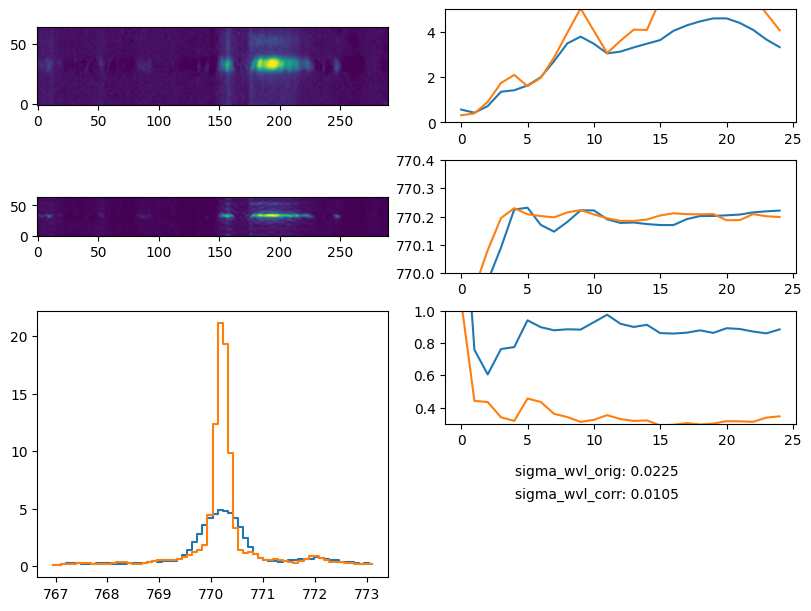

In [91]:
# parameter set 1
yl_core_xpo = 1.8
yl_wing_xpo = 1

# Rotation angle of the PSF, both core and wings
psf_yl_angle = -10*np.pi/180

# FWHMs of PSF core. First argument is width along y axis before rotation,
# and is in arcseconds. Second is along lambda axis and is in angstrom.
fwhm_core0_yl = np.array([1.5, 1.11])

# This descriptor for plots should be manually edited to reflect the PSF parameters
gaussian_desc = '2-part Gaussian PSF'

fwhm_wing0_yl = np.array([8.0, 4.5]) # FWHMs of PSF wings in arcseconds and angstroms, respectively
desc_str='; standard wing aspect ratio'

# Fraction of overall PSF amplitude in wings (core weight is 1.0 - wing_weight).
# PSFs have unit peak amplitude, -- PLEASE NOTE: they do not integrate to 1.
wing_weight = 0.28

work((test_NeVIII_data_bin_trans, spice_hdr_20_NeVIII,
fwhm_core0_yl, fwhm_wing0_yl, psf_yl_angle, wing_weight, 
yl_core_xpo,yl_wing_xpo, rebin_facs,NeVIII_row_20_orig_fit_int,
NeVIII_row_20_orig_fit_wvl, NeVIII_row_20_orig_fit_wid,
test_fit_NeVIII_wvl))

Correcting Full SW 4:1 Focal Lossy; ref. wavelength=766.8564825000001
Computing PSF Core:
4.9948811897192735 % done after 1.3745369911193848 seconds
9.99515060078668 % done after 2.748389720916748 seconds
14.995420011854087 % done after 4.125971794128418 seconds
19.995689422921494 % done after 5.5063018798828125 seconds
24.9959588339889 % done after 6.889074325561523 seconds
29.996228245056308 % done after 8.268928289413452 seconds
34.996497656123715 % done after 9.648618698120117 seconds
39.99676706719112 % done after 11.029400110244751 seconds
44.99703647825853 % done after 12.41218376159668 seconds
49.997305889325936 % done after 13.796451091766357 seconds
54.99757530039334 % done after 15.178240537643433 seconds
59.99784471146074 % done after 16.56303572654724 seconds
64.99811412252815 % done after 17.947959184646606 seconds
69.99838353359556 % done after 19.33142590522766 seconds
74.99865294466296 % done after 20.71322536468506 seconds
79.99892235573037 % done after 22.09808540344

2025-03-04 16:06:51 - root - INFO: Processed: (array([1.5 , 1.11]), array([8. , 4.5]), -0.17453292519943295, 0.28, 1.8)


3.632086992263794 s; Finished slit index 1 of 2 , chi^2= 0.22425459386129817
{'det_scale0': array([16.36363636, 36.        , 19.5034    ]), 'det_dims0': array([  2, 290,  64]), 'det_origin0': array([     0.    ,      0.    , 153371.2965]), 'src_dims0': array([  2, 290,  64]), 'src_origin0': array([     0.    ,      0.    , 153371.2965]), 'src_scale0': array([16.36363636, 36.        , 19.5034    ]), 'fwhm_core_yl': array([ 24.54545455, 222.        ]), 'fwhm_wing_yl': array([130.90909091, 900.        ]), 'psf_yl_angle': -0.17453292519943295, 'fwhm_symm': array([36., 36.])}


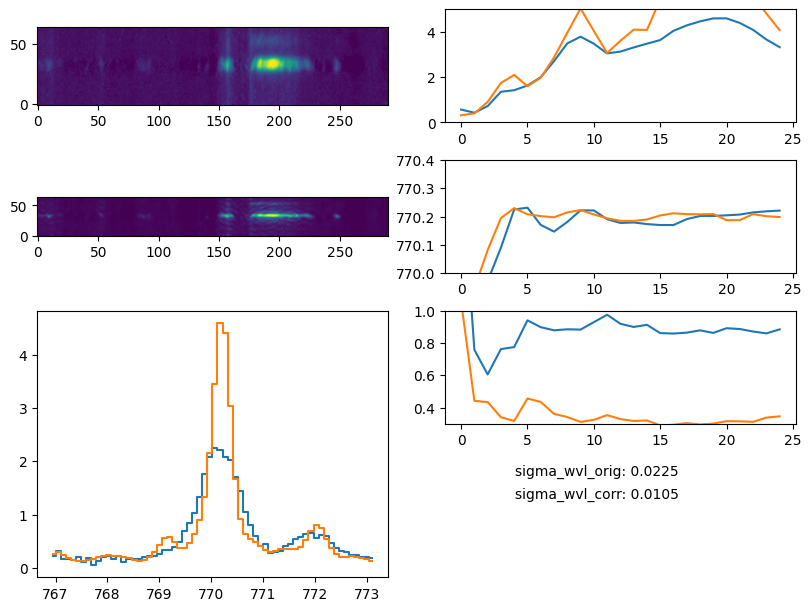

In [92]:
# parameter set 1
yl_core_xpo = 1.8
yl_wing_xpo = 1

# Rotation angle of the PSF, both core and wings
psf_yl_angle = -10*np.pi/180

# FWHMs of PSF core. First argument is width along y axis before rotation,
# and is in arcseconds. Second is along lambda axis and is in angstrom.
fwhm_core0_yl = np.array([1.5, 1.11])

# This descriptor for plots should be manually edited to reflect the PSF parameters
gaussian_desc = '2-part Gaussian PSF'

fwhm_wing0_yl = np.array([8.0, 4.5]) # FWHMs of PSF wings in arcseconds and angstroms, respectively
desc_str='; standard wing aspect ratio'

# Fraction of overall PSF amplitude in wings (core weight is 1.0 - wing_weight).
# PSFs have unit peak amplitude, -- PLEASE NOTE: they do not integrate to 1.
wing_weight = 0.28

work((test_NeVIII_data_bin_trans, spice_hdr_20_NeVIII,
fwhm_core0_yl, fwhm_wing0_yl, psf_yl_angle, wing_weight, 
yl_core_xpo,yl_wing_xpo, rebin_facs,NeVIII_row_20_orig_fit_int,
NeVIII_row_20_orig_fit_wvl, NeVIII_row_20_orig_fit_wid,
test_fit_NeVIII_wvl), position=363//2)